# SUPERVISED MACHINE LEARNING MODEL

In [31]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

Using the same logic from the Bovy Paper as in the metadata_eda.ipynb file

In [15]:
data_array = np.load('processed_labels.npy')

column_names = ['RV_TEFF', 'RV_FEH', 'RV_LOGG']
df = pd.DataFrame(data_array, columns=column_names)

t_ref = -382.5 * df['RV_FEH'] + 4607
delta_t = df['RV_TEFF'] - t_ref
logg_upper_bound = (0.0018 * delta_t) + 2.5

rc_mask = df["RV_LOGG"].between(1.8, logg_upper_bound)
df["Class"] = np.where(rc_mask, "Red Clump", "Red Giant")
df["Class_binary"] = np.where(rc_mask, 1, 0)

In [16]:
df.head()

,RV_TEFF,RV_FEH,RV_LOGG,Class,Class_binary
0,4408.2754,-0.141393,1.834175,Red Clump,1
1,4760.7430,-0.001102,2.494274,Red Clump,1
2,4591.3230,-0.795493,2.551696,Red Giant,0
3,4354.9640,-0.212246,2.076391,Red Giant,0
4,4834.4980,-0.552180,3.045213,Red Giant,0


In [17]:
df["Class"].value_counts()

Class
Red Giant    8973
Red Clump    3927
Name: count, dtype: int64

### PREPROCESSING

In [18]:
df = df.reset_index(drop=True)
x = np.load('processed_spectra.npy')

In [57]:
# Balancing classes to improve classification training
df_giants = df[df["Class_binary"] == 0]
df_clumps = df[df["Class_binary"] == 1]

df_giants_downsampled = df_giants.sample(n=len(df_clumps), random_state=42)
df_balanced = pd.concat([df_giants_downsampled, df_clumps]).sample(frac=1, random_state=42)

balanced_positions = df_balanced.index.values
x_balanced = x[balanced_positions]
y_balanced = df_balanced["Class_binary"].values

In [ ]:
# 20% split for final test data
indices = np.arange(len(x_balanced))
train_val_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)

# 20% of the remaing from test data for validation, the rest (60% of original data) is training
train_idx, val_idx = train_test_split(train_val_idx, test_size=0.2, random_state=42)

x_train_raw = x_balanced[train_idx]
y_train = y_balanced[train_idx]

x_val_raw = x_balanced[val_idx]
y_val = y_balanced[val_idx]

x_test_raw = x_balanced[test_idx]
y_test_encoded = y_balanced[test_idx]

In [ ]:
def process_spectra(data_raw):
    # Clean NaNs
    data_raw = np.nan_to_num(data_raw, nan=1.0, posinf=1.0, neginf=0.0)
    
    flux_raw = data_raw[:, 0, :]
    error_raw = data_raw[:, 1, :]
    
    # Normalize flux
    flux_norm = np.clip(flux_raw, 0, 1.5) 
    
    # Gradient
    flux_grad = np.gradient(flux_norm, axis=-1) * 10.0
    
    # Normalize error
    error_norm = np.clip(error_raw, 0, 1.0)
    
    return np.stack([flux_norm, flux_grad, error_norm], axis=-1)

x_train = process_spectra(x_train_raw)
x_val = process_spectra(x_val_raw)
x_test = process_spectra(x_test_raw)

In [56]:
x_train.shape

(5026, 8575, 3)

### MODEL

In [ ]:
def build_improved_cnn(input_shape):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        
        # To catch narrow features
        layers.Conv1D(32, kernel_size=7, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        
        # To catch broad features
        layers.Conv1D(64, kernel_size=11, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        
        # Abstraction
        layers.Conv1D(128, kernel_size=11, padding='same', activation='relu'),
        layers.GlobalMaxPooling1D(),
        
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

input_shape = (x_train.shape[1], 3) 
model = build_improved_cnn(input_shape)

In [25]:
tensorboard_callback = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5)

history = model.fit(
    x_train, y_train,
    epochs=50, 
    batch_size=16,
    validation_data=(x_val, y_val),
    shuffle=True,
    callbacks=[tensorboard_callback]
)

model.save("apogee_supervised_v1.keras")

Epoch 1/50


I0000 00:00:1776437979.989305  133276 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_12434__.40
I0000 00:00:1776437982.527485  136087 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_select_transpose_fusion', 192 bytes spill stores, 192 bytes spill loads



312/315 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6182 - loss: 1.0553

I0000 00:00:1776437992.118473  133273 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_12434__.40


315/315 ━━━━━━━━━━━━━━━━━━━━ 18s 34ms/step - accuracy: 0.7129 - loss: 0.6652 - val_accuracy: 0.7661 - val_loss: 0.5057
Epoch 2/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.8478 - loss: 0.3301 - val_accuracy: 0.8846 - val_loss: 0.2772
Epoch 3/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8792 - loss: 0.2747 - val_accuracy: 0.8831 - val_loss: 0.2605
Epoch 4/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.8947 - loss: 0.2429 - val_accuracy: 0.8926 - val_loss: 0.2502
Epoch 5/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9142 - loss: 0.2226 - val_accuracy: 0.8703 - val_loss: 0.2830
Epoch 6/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9194 - loss: 0.2071 - val_accuracy: 0.9045 - val_loss: 0.2307
Epoch 7/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.9240 - loss: 0.1902 - val_accuracy: 0.8894 - val_loss: 0.2392
Epoch 8/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9248 - loss: 0.1821 - val_accuracy: 0.9

### Evaluating Model

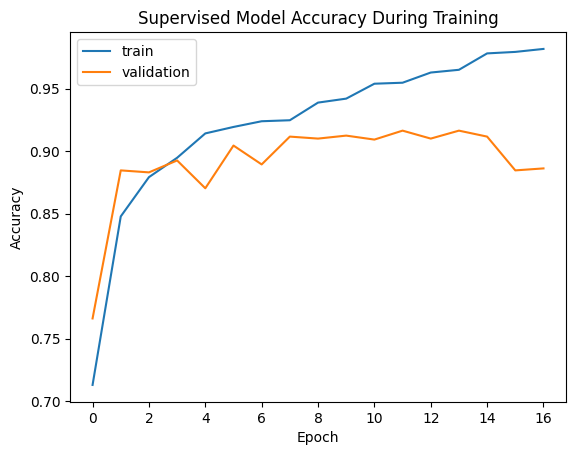

In [ ]:
# Accuracy during training plot
def plot_history(history):
    plt.plot(history.history['accuracy'], label='train')
    plt.plot(history.history['val_accuracy'], label='validation')
    plt.title('Supervised Model Accuracy During Training')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

plot_history(history)

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


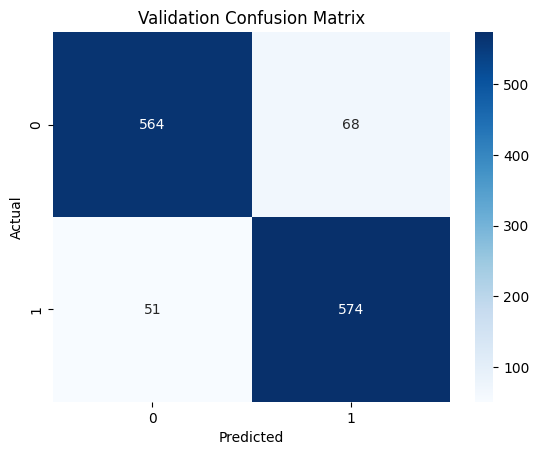

In [55]:
# Confusion matrix to visualize true positives and true negatives
# highest overall accuracy with threshold > 0.9
y_val_pred = (model.predict(x_val) > 0.9).astype(int)
cm = confusion_matrix(y_val, y_val_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Validation Confusion Matrix')
plt.show()

### RESULTS

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


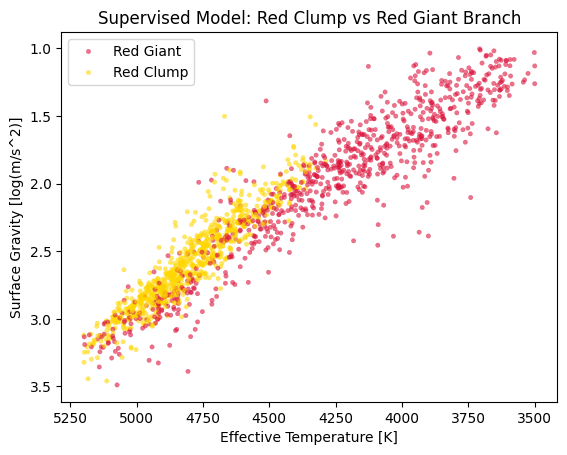

In [54]:
# Get predictions for test set
y_test_prob = model.predict(x_test)
y_test_pred = (y_test_prob > 0.9).astype(int).flatten()

# Compile data for plotting
df_plot = df_balanced.iloc[test_idx].copy()
df_plot['Stellar_type'] = np.where(y_test_pred == 1, "Red Clump", "Red Giant")

# Plotting
sns.scatterplot(
    data=df_plot, 
    x="RV_TEFF", 
    y="RV_LOGG", 
    hue="Stellar_type", 
    palette={"Red Clump": "#FFD700", "Red Giant": "#DC143C"},
    s=10, 
    alpha=0.6,
    edgecolor=None
)

plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.xlabel("Effective Temperature [K]")
plt.ylabel("Surface Gravity [log(m/s^2)]")
plt.title("Supervised Model: Red Clump vs Red Giant Branch")
plt.legend(loc='upper left')
plt.show()